# Griffiths QM
## Chapter 7: Time-Independent Perturbation Theory — Visualizations

**Repository:** [SeoulTechPSE/introduction_to_quantum_mechanics](https://github.com/SeoulTechPSE/introduction_to_quantum_mechanics)

| Section | Problem |
|:--------|:--------|
| [Problem 7.3](#prob_7_3)   | Anharmonic Oscillator — Energy Corrections |
| [Problem 7.4](#prob_7_4)   | ISW with Slanted Floor |
| [Problem 7.6](#prob_7_6)   | Charged HO in Electric Field: Exact vs Perturbation |
| [Problem 7.9](#prob_7_9)   | Fine Structure of Hydrogen — Level Diagram |
| [Problem 7.10](#prob_7_10) | Zeeman Effect — Weak Field |
| [Problem 7.11](#prob_7_11) | Zeeman Effect — Strong Field (Paschen-Back) |
| [Problem 7.15](#prob_7_15) | Stark Effect — Hydrogen in Electric Field |
| [Problem 7.18](#prob_7_18) | van der Waals Interaction |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

plt.rcParams.update({'figure.dpi':120,'axes.labelsize':12,'axes.titlesize':13,
    'legend.fontsize':10,'font.family':'serif','mathtext.fontset':'cm'})
BLUE='#2471a3'; RED='#c0392b'; GREEN='#1e8449'; GRAY='#7f8c8d'; NAVY='#1a3a5c'; PURP='#8e44ad'
figures = []


---
## Problem 7.3 — Anharmonic Oscillator {#prob_7_3}

First-order correction for $H' = \lambda x^4$:

$$E_n^1 = \frac{3\lambda\hbar^2}{4m^2\omega^2}(2n^2+2n+1)$$

Second-order correction for $H' = \lambda x^3$:

$$E_n^2 = -\frac{11\lambda^2\hbar^2}{4m^3\omega^4}\!\left(n+\frac{1}{2}\right)$$


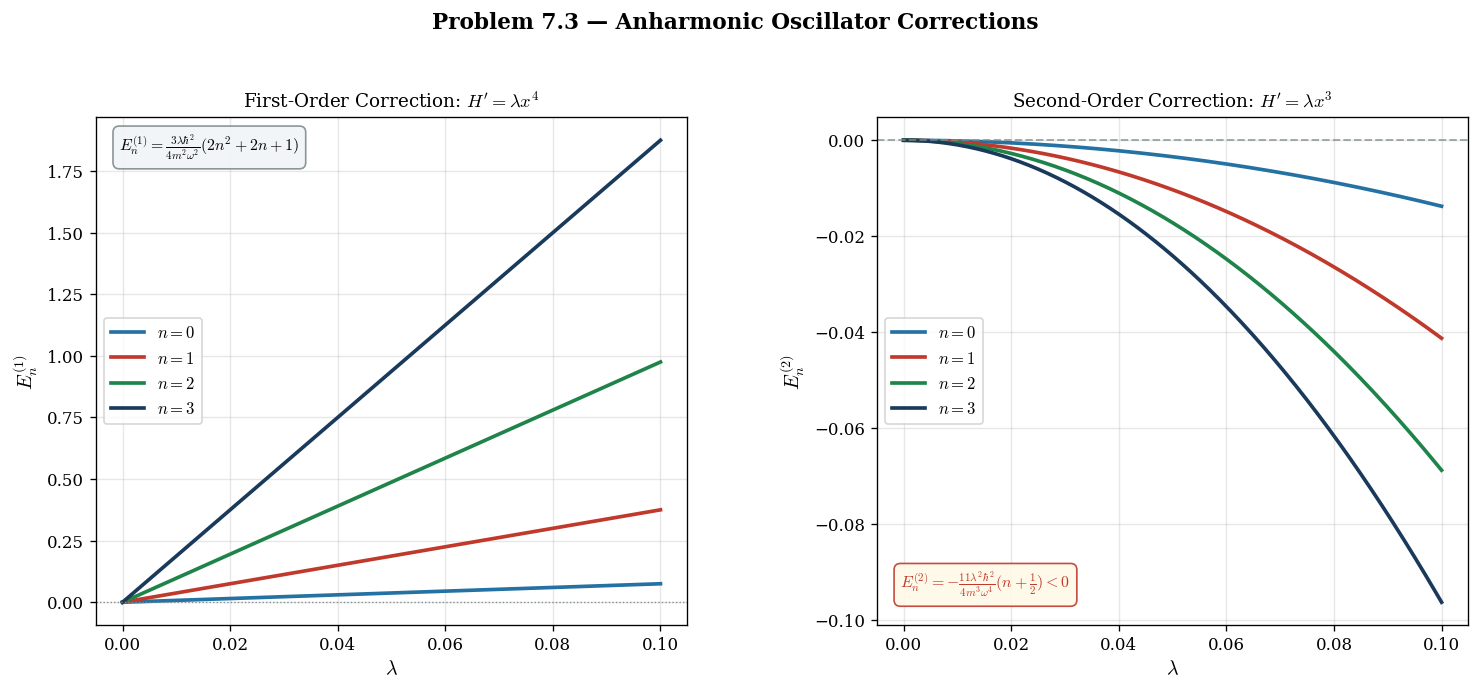

x^4 first-order: E_n^1 = (3*lambda*hbar^2)/(4*m^2*omega^2) * (2n^2+2n+1)
n=0: coefficient = 0.7500  (= 3/4)
x^3 second-order: always negative (ground state lowers) ✓


In [2]:
# Figure 7.3: Anharmonic oscillator energy corrections
hbar = 1.0; m = 1.0; omega = 1.0
n_vals  = [0, 1, 2, 3]
lam_arr = np.linspace(0, 0.1, 300)
col_n   = [BLUE, RED, GREEN, NAVY]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.32)
fig.suptitle('Problem 7.3 — Anharmonic Oscillator Corrections', fontsize=13, fontweight='bold', y=1.04)

# Left: x^4 first-order
ax = axes[0]
for n, c in zip(n_vals, col_n):
    E1 = (3*lam_arr*hbar**2 / (4*m**2*omega**2)) * (2*n**2 + 2*n + 1)
    ax.plot(lam_arr, E1, color=c, lw=2.2, label=fr'$n={n}$')
ax.set_xlabel(r'$\lambda$', labelpad=3)
ax.set_ylabel(r'$E_n^{(1)}$')
ax.set_title(r'First-Order Correction: $H^\prime = \lambda x^4$', fontsize=11)
ax.axhline(0, color=GRAY, lw=0.8, ls=':')
ax.legend(fontsize=10, loc='center left')
ax.grid(True, alpha=0.3)
# Fixed-position textbox (avoid get_ylim before draw)
ax.text(0.04, 0.97,
        r'$E_n^{(1)} = \frac{3\lambda\hbar^2}{4m^2\omega^2}(2n^2+2n+1)$',
        transform=ax.transAxes, fontsize=9.5, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', fc='#f0f4f8', ec=GRAY, alpha=0.9))

# Right: x^3 second-order
ax2 = axes[1]
for n, c in zip(n_vals, col_n):
    E2 = -(11*lam_arr**2*hbar**2 / (4*m**3*omega**4)) * (n + 0.5)
    ax2.plot(lam_arr, E2, color=c, lw=2.2, label=fr'$n={n}$')
ax2.axhline(0, color=GRAY, lw=1.2, ls='--', alpha=0.7)
ax2.set_xlabel(r'$\lambda$', labelpad=3)
ax2.set_ylabel(r'$E_n^{(2)}$')
ax2.set_title(r'Second-Order Correction: $H^\prime = \lambda x^3$', fontsize=11)
ax2.legend(fontsize=10, loc='center left')
ax2.grid(True, alpha=0.3)
ax2.text(0.04, 0.05,
         r'$E_n^{(2)} = -\frac{11\lambda^2\hbar^2}{4m^3\omega^4}(n+\frac{1}{2}) < 0$',
         transform=ax2.transAxes, fontsize=9.5, va='bottom', ha='left', color=RED,
         bbox=dict(boxstyle='round,pad=0.4', fc='#fef9e7', ec=RED, alpha=0.9))

figures.append((fig, 'fig_7_3.png')); plt.show()
print('x^4 first-order: E_n^1 = (3*lambda*hbar^2)/(4*m^2*omega^2) * (2n^2+2n+1)')
print(f'n=0: coefficient = {3/4:.4f}  (= 3/4)')
print('x^3 second-order: always negative (ground state lowers) ✓')


---
## Problem 7.4 — ISW with Slanted Floor {#prob_7_4}

Perturbation: $H^\prime = \epsilon\,x/a$

First-order correction: $E_n^1 = \epsilon/2$ (independent of $n$)


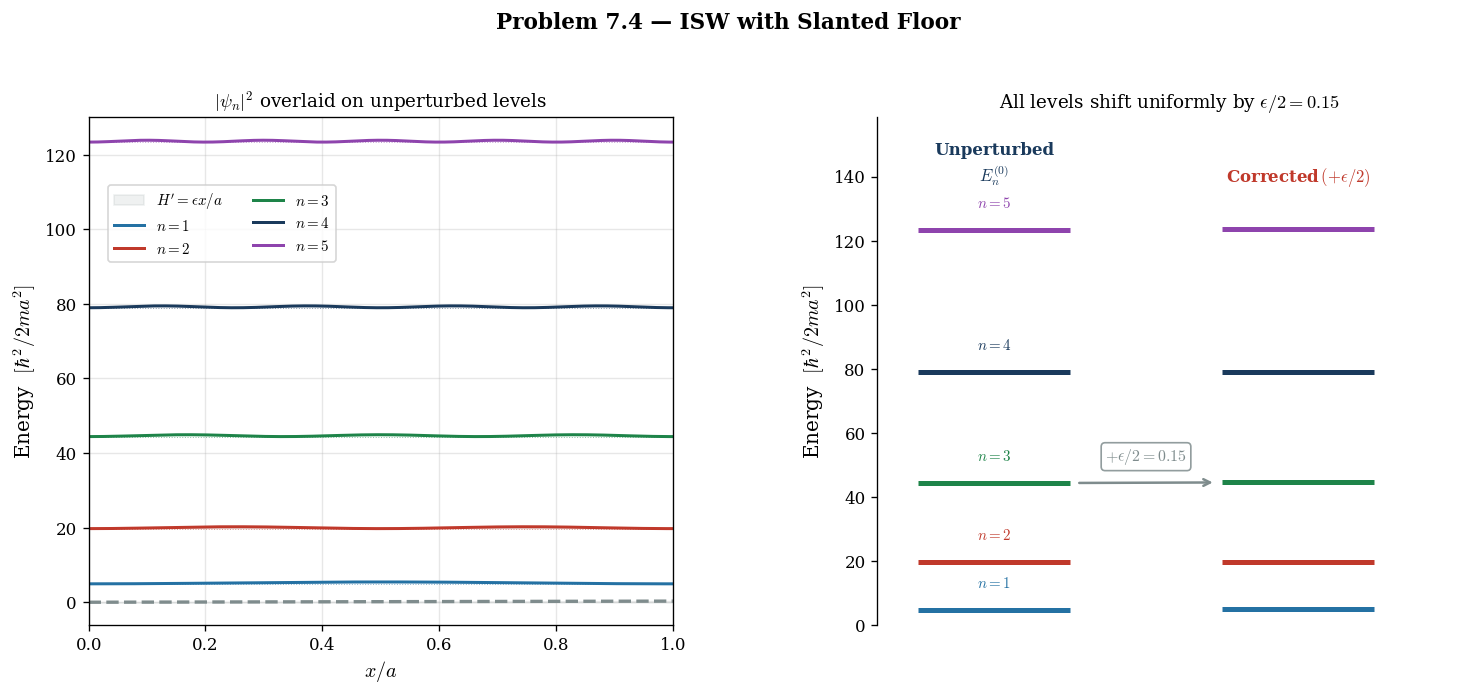

E_n^1 = epsilon/2 = 0.1500  for ALL n  ✓


In [3]:
a = 1.0; eps = 0.3
ns_show = [1, 2, 3, 4, 5]
col_n   = [BLUE, RED, GREEN, NAVY, PURP]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.35)
fig.suptitle('Problem 7.4 — ISW with Slanted Floor', fontsize=13, fontweight='bold', y=1.04)

# Left: wavefunctions + perturbation
ax = axes[0]
x   = np.linspace(0, a, 500)
Vp  = eps * x / a
ax.fill_between(x, 0, Vp, alpha=0.12, color=GRAY, label=r"$H' = \epsilon x/a$")
ax.plot(x, Vp, color=GRAY, lw=2.0, ls='--')
for n, c in zip(ns_show, col_n):
    E0   = n**2 * np.pi**2 / 2   # hbar=m=a=1
    psi2 = (2/a) * np.sin(n*np.pi*x/a)**2
    ax.plot(x, psi2*0.25 + E0, color=c, lw=1.8, label=fr'$n={n}$'
)
    ax.axhline(E0, color=c, lw=0.6, ls=':', alpha=0.5)
ax.set_xlabel(r'$x/a$', labelpad=3)
ax.set_ylabel(r'Energy  $[\hbar^2/2ma^2]$')
ax.set_title(r'$|\psi_n|^2$ overlaid on unperturbed levels', fontsize=11)
ax.legend(fontsize=9, ncol=2, bbox_to_anchor=(0.02,0.7))
ax.grid(True, alpha=0.3)
ax.set_xlim(0, a)

# Right: level diagram — unperturbed vs corrected (no arrows, use color + offset)
ax2 = axes[1]
E1 = eps / 2   # uniform shift
X_L, X_R = 0.20, 0.72   # x-centres of two column groups

for i, (n, c) in enumerate(zip(ns_show, col_n)):
    E0 = n**2 * np.pi**2 / 2
    # unperturbed
    ax2.hlines(E0,        X_L-0.13, X_L+0.13, color=c, lw=3.0)
    ax2.text(X_L, E0 + 6, f'$n={n}$', ha='center', va='bottom',
             fontsize=9, color=c)
    # corrected
    ax2.hlines(E0 + E1,   X_R-0.13, X_R+0.13, color=c, lw=3.0)

# Column headers
y_top = ns_show[-1]**2 * np.pi**2 / 2 + E1 + 15
ax2.text(X_L, y_top, 'Unperturbed\n$E_n^{(0)}$',
         ha='center', fontsize=10, fontweight='bold', color=NAVY)
ax2.text(X_R, y_top, fr'Corrected$\,(+\epsilon/2)$',
         ha='center', fontsize=10, fontweight='bold', color=RED)

# Uniform shift arrow (between columns, at n=3 level)
n_arr = 3; E_arr_y = n_arr**2*np.pi**2/2
ax2.annotate('', xy=(X_R-0.14, E_arr_y+E1),
             xytext=(X_L+0.14, E_arr_y),
             arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))
ax2.text((X_L+X_R)/2, E_arr_y + E1/2 +5,
         fr'$+\epsilon/2 = {E1:.2f}$',
         ha='center', va='bottom', fontsize=9.5, color=GRAY,
         bbox=dict(boxstyle='round,pad=0.25', fc='white', ec=GRAY, alpha=0.85))

ax2.set_xlim(0, 1); ax2.set_ylim(0, y_top + 20)
ax2.set_ylabel(r'Energy  $[\hbar^2/2ma^2]$')
ax2.set_title(fr'All levels shift uniformly by $\epsilon/2 = {E1:.2f}$', fontsize=11)
ax2.set_xticks([])
for sp in ['top','right','bottom']: ax2.spines[sp].set_visible(False)
ax2.grid(False)

figures.append((fig, 'fig_7_4.png')); plt.show()
print(f'E_n^1 = epsilon/2 = {E1:.4f}  for ALL n  ✓')

---
## Problem 7.6 — Charged HO in Electric Field: Exact vs Perturbation {#prob_7_6}

Exact: $E_n = (n+\tfrac{1}{2})\hbar\omega - q^2\mathcal{E}^2/(2m\omega^2)$

Perturbation (2nd order): same — perturbation theory is exact here.


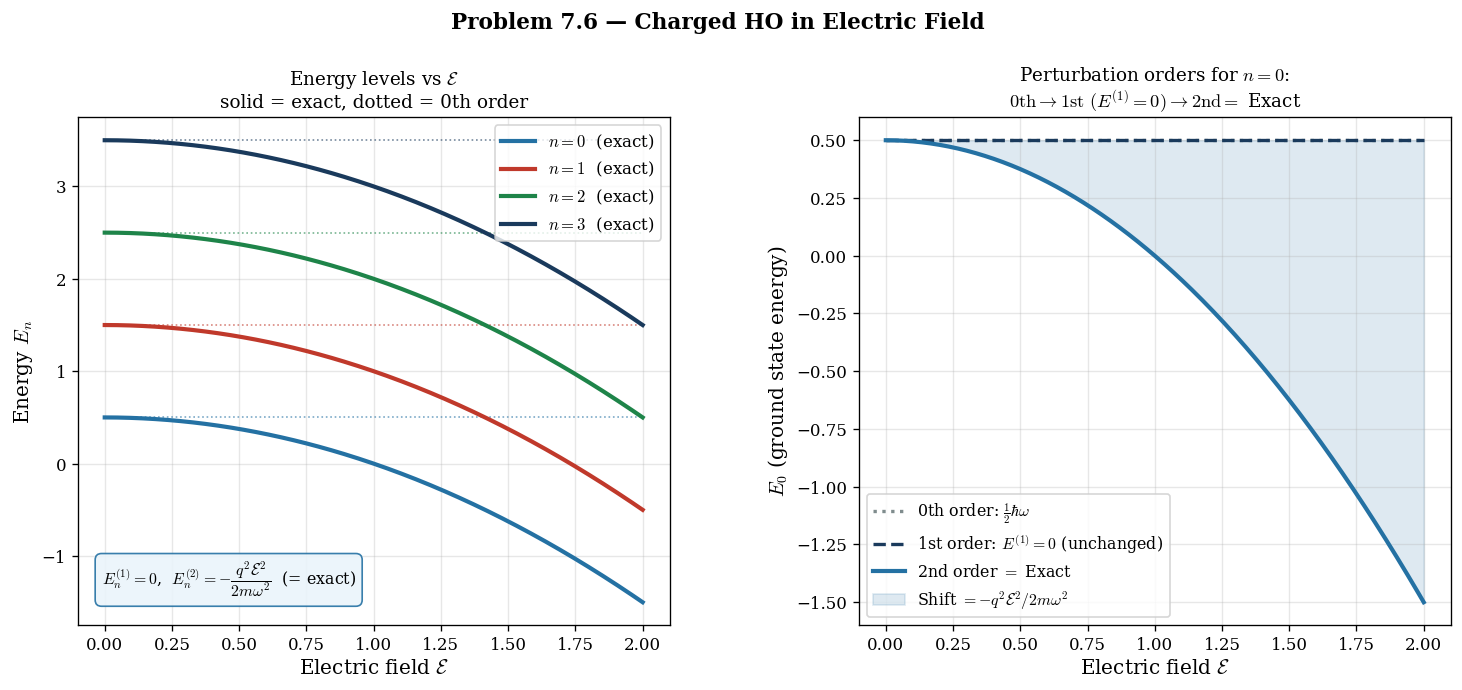

E^1 = 0  (since <x> = 0 for HO states)
E^2 = exact shift  (series terminates at 2nd order) ✓


In [4]:
# Figure 7.6: Charged HO in electric field
hbar = 1.0; m = 1.0; omega = 1.0; q = 1.0
E_arr  = np.linspace(0, 2.0, 300)
n_vals = [0, 1, 2, 3]
col_n  = [BLUE, RED, GREEN, NAVY]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.32)
fig.suptitle('Problem 7.6 — Charged HO in Electric Field', fontsize=13, fontweight='bold', y=1.04)

# Left: energy levels vs field
ax = axes[0]
for n, c in zip(n_vals, col_n):
    E_exact = (n + 0.5)*hbar*omega - q**2*E_arr**2/(2*m*omega**2)
    ax.plot(E_arr, E_exact, color=c, lw=2.5, label=fr'$n={n}$  (exact)')
    ax.plot(E_arr, (n+0.5)*np.ones_like(E_arr), color=c, lw=1.0, ls=':', alpha=0.6)
ax.set_xlabel(r'Electric field $\mathcal{E}$', labelpad=3)
ax.set_ylabel(r'Energy $E_n$')
ax.set_title(r'Energy levels vs $\mathcal{E}$' + '\n'
             r'solid = exact, dotted = 0th order', fontsize=11)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.text(0.04, 0.05,
        r'$E_n^{(1)}=0$,  $E_n^{(2)}=-\dfrac{q^2\mathcal{E}^2}{2m\omega^2}$  (= exact)',
        transform=ax.transAxes, fontsize=9.5, va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', fc='#eaf4fb', ec=BLUE, alpha=0.9))

# Right: order-by-order for n=0
shift   = q**2 * E_arr**2 / (2*m*omega**2)
E0_0th  = 0.5*hbar*omega * np.ones_like(E_arr)
E0_ex   = 0.5*hbar*omega - shift

ax2 = axes[1]
ax2.plot(E_arr, E0_0th, color=GRAY, lw=2.0, ls=':',
         label=r'0th order: $\frac{1}{2}\hbar\omega$')
ax2.plot(E_arr, E0_0th, color=NAVY, lw=2.0, ls='--',
         label=r'1st order: $E^{(1)}=0$ (unchanged)')
ax2.plot(E_arr, E0_ex,  color=BLUE, lw=2.5,
         label=r'2nd order $=$ Exact')
ax2.fill_between(E_arr, E0_0th, E0_ex, alpha=0.15, color=BLUE,
                 label=r'Shift $= -q^2\mathcal{E}^2/2m\omega^2$')
ax2.set_xlabel(r'Electric field $\mathcal{E}$', labelpad=3)
ax2.set_ylabel(r'$E_0$ (ground state energy)')
ax2.set_title('Perturbation orders for $n=0$:\n'
              r'$0\mathrm{th} \to 1\mathrm{st}\ (E^{(1)}=0) \to 2\mathrm{nd}=$ Exact',
              fontsize=11)
ax2.legend(fontsize=9.5, loc='lower left')
ax2.grid(True, alpha=0.3)

figures.append((fig, 'fig_7_6.png')); plt.show()
print('E^1 = 0  (since <x> = 0 for HO states)')
print('E^2 = exact shift  (series terminates at 2nd order) ✓')


---
## Problem 7.9 — Fine Structure of Hydrogen {#prob_7_9}

$$E_{nj}^{fs} = -\frac{13.6\,\text{eV}}{n^2}
\left[1+\frac{\alpha^2}{n^2}\left(\frac{n}{j+\frac{1}{2}}-\frac{3}{4}\right)\right]$$


Fine structure energies:
  $1s_{1/2}$: -13600.181 meV  (shift = -1811.4977 ×10⁻⁴ eV)
  $2s_{1/2}$: -3400.057 meV  (shift = -566.0930 ×10⁻⁴ eV)
  $2p_{1/2}$: -3400.057 meV  (shift = -566.0930 ×10⁻⁴ eV)
  $2p_{3/2}$: -3400.011 meV  (shift = -113.2186 ×10⁻⁴ eV)
  $3s_{1/2}$: -1511.131 meV  (shift = -201.2775 ×10⁻⁴ eV)
  $3p_{1/2}$: -1511.131 meV  (shift = -201.2775 ×10⁻⁴ eV)
  $3p_{3/2}$: -1511.118 meV  (shift = -67.0925 ×10⁻⁴ eV)
  $3d_{3/2}$: -1511.118 meV  (shift = -67.0925 ×10⁻⁴ eV)
  $3d_{5/2}$: -1511.113 meV  (shift = -22.3642 ×10⁻⁴ eV)


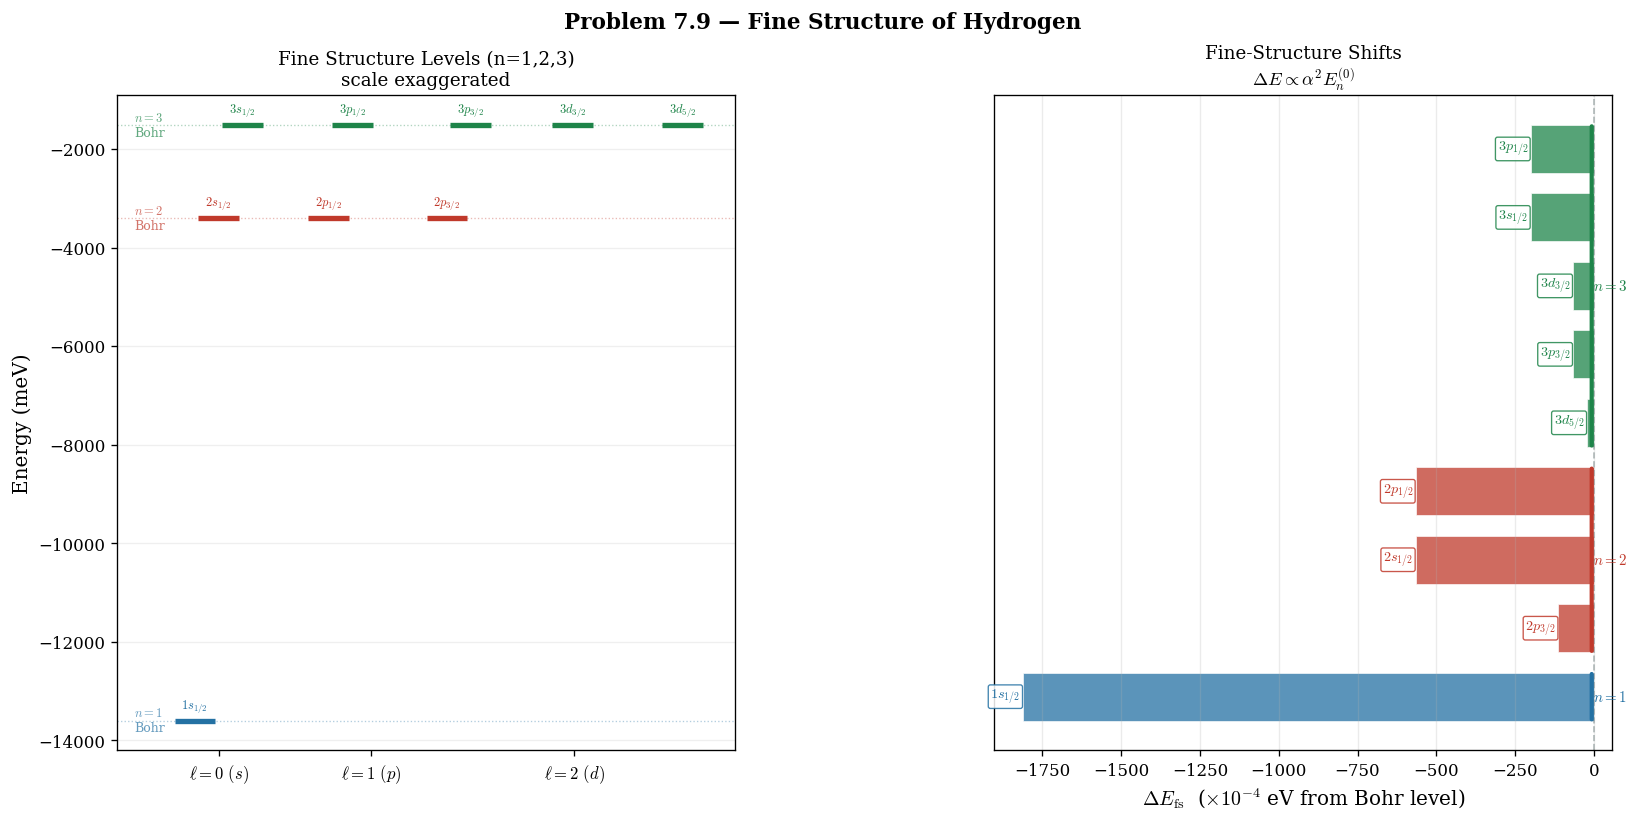

In [5]:
# Figure 7.9: Fine structure of hydrogen
from matplotlib.gridspec import GridSpec

alpha = 1/137.0

def E_bohr(n):  return -13600.0 / n**2   # meV

def E_fs(n, j):
    return E_bohr(n) * (1 + (alpha**2/n**2) * (n/(j+0.5) - 0.75))

levels = [
    (1, 0, 0.5, r'$1s_{1/2}$'),
    (2, 0, 0.5, r'$2s_{1/2}$'),
    (2, 1, 0.5, r'$2p_{1/2}$'),
    (2, 1, 1.5, r'$2p_{3/2}$'),
    (3, 0, 0.5, r'$3s_{1/2}$'),
    (3, 1, 0.5, r'$3p_{1/2}$'),
    (3, 1, 1.5, r'$3p_{3/2}$'),
    (3, 2, 1.5, r'$3d_{3/2}$'),
    (3, 2, 2.5, r'$3d_{5/2}$'),
]
n_col = {1: BLUE, 2: RED, 3: GREEN}

fig = plt.figure(figsize=(14, 7))
gs  = GridSpec(1, 2, figure=fig, left=0.08, right=0.97,
               top=0.88, bottom=0.10, wspace=0.42)
fig.suptitle('Problem 7.9 — Fine Structure of Hydrogen', fontsize=13, fontweight='bold')

# ── Left: absolute levels ─────────────────────────────────────────────
ax = fig.add_subplot(gs[0])

# Each (l, j, n) gets a unique x so labels never overlap.
# Columns: s(l=0) at x~0.5, p_1/2 at ~1.1, p_3/2 at ~1.7, d_3/2 at ~2.3, d_5/2 at ~2.9
# Within each (l,j) column the three n values are spaced ±0.10
x_base = {(0,0.5): 0.50, (1,0.5): 1.15, (1,1.5): 1.85, (2,1.5): 2.45, (2,2.5): 3.10}
n_dx   = {1: -0.14, 2: 0.00, 3: +0.14}   # 간격 0.10 → 0.14로 확대

for n, l, j, lbl in levels:
    E  = E_fs(n, j)
    xc = x_base[(l, j)] + n_dx[n]
    c  = n_col[n]
    ax.hlines(E, xc-0.12, xc+0.12, color=c, lw=3.2, zorder=3)  # 0.07 → 0.12
    ax.text(xc, E + 120, lbl, va='bottom', ha='center',
            fontsize=7.5, color=c, rotation=0)

for n, c in n_col.items():
    ax.axhline(E_bohr(n), color=c, lw=0.8, ls=':', alpha=0.35)
    ax.text(0.0, E_bohr(n), f'$n={n}$\nBohr',
            va='center', ha='left', fontsize=7.5, color=c, alpha=0.7)

ax.set_ylabel('Energy (meV)', labelpad=4)
ax.set_title('Fine Structure Levels (n=1,2,3)\nscale exaggerated', fontsize=11)

# x-ticks at column-group centres
ax.set_xticks([0.50, 1.40, 2.60])
ax.set_xticklabels([r'$\ell=0\ (s)$', r'$\ell=1\ (p)$', r'$\ell=2\ (d)$'], fontsize=10)
ax.set_xlim(-0.10, 3.55)
ax.grid(True, alpha=0.2, axis='y')

# ── Right: fine-structure shifts ─────────────────────────────
ax2 = fig.add_subplot(gs[1])

state_data = []
for n, l, j, lbl in levels:
    dE = (E_fs(n, j) - E_bohr(n)) * 1e4   # ×10⁻⁴ eV
    state_data.append((n, lbl, dE, n_col[n]))

# Sort: within each n, largest shift (least negative) at top
state_data.sort(key=lambda x: (x[0], -x[2]))
ys     = np.arange(len(state_data))
shifts = np.array([d[2] for d in state_data])
colors = [d[3] for d in state_data]
labels = [d[1] for d in state_data]

ax2.barh(ys, shifts, color=colors, alpha=0.75, height=0.70,
         edgecolor='white', lw=0.5)

# Label at right end of each bar (bar goes left → label at shift value, outside)
ax2.set_yticks([])
for i, (lbl, shift, c) in enumerate(zip(labels, shifts, colors)):
    ax2.text(shift - 8,   # just left of bar's right end (bar end = 0, left tip = shift)
             i, lbl,
             va='center', ha='right', fontsize=8.5, color=c, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=c, lw=0.8, alpha=0.85))

ax2.axvline(0, color=GRAY, lw=1.0, ls='--', alpha=0.6)
ax2.set_xlabel(r'$\Delta E_{\rm fs}$  ($\times10^{-4}$ eV from Bohr level)', labelpad=4)
ax2.set_title('Fine-Structure Shifts\n' + r'$\Delta E \propto \alpha^2 E_n^{(0)}$', fontsize=11)
ax2.grid(True, alpha=0.25, axis='x')

# n-group bracket on right
x_right = shifts.max() + 15
for n, c in n_col.items():
    idxs = [i for i, d in enumerate(state_data) if d[0] == n]
    y0, y1 = min(idxs) - 0.38, max(idxs) + 0.38
    ax2.annotate('', xy=(x_right, y0), xytext=(x_right, y1),
                 arrowprops=dict(arrowstyle='-', color=c, lw=2.5),
                 annotation_clip=False)
    ax2.text(x_right + 5, (y0+y1)/2, f'$n={n}$',
             ha='left', va='center', fontsize=9, color=c,
             fontweight='bold', clip_on=False)

ax2.set_xlim(shifts.min() * 1.05, shifts.max() + 80)

# Physics checks
print('Fine structure energies:')
for n, l, j, lbl in levels:
    E  = E_fs(n, j)
    dE = (E - E_bohr(n)) * 1e4
    print(f'  {lbl}: {E:.3f} meV  (shift = {dE:.4f} ×10⁻⁴ eV)')

figures.append((fig, 'fig_7_9.png')); plt.show()

---
## Problem 7.10 & 7.11 — Zeeman Effect: Weak & Strong Field {#prob_7_10}

**Weak field (Landé g-factor):**
$$\Delta E_Z = \mu_B g_J m_j B, \quad
g_J = 1 + \frac{j(j+1)+s(s+1)-l(l+1)}{2j(j+1)}$$

**Strong field (Paschen-Back):**
$$\Delta E_{PB} = \mu_B(m_l + 2m_s)B + A\,m_l m_s$$


Landé g-factors for 2p state:
  j=0.5: g_J = 0.6667
  j=1.5: g_J = 1.3333
Paschen-Back: ml+2ms values for 2p = [-2.0, -1.0, 0.0, 1.0, 2.0]


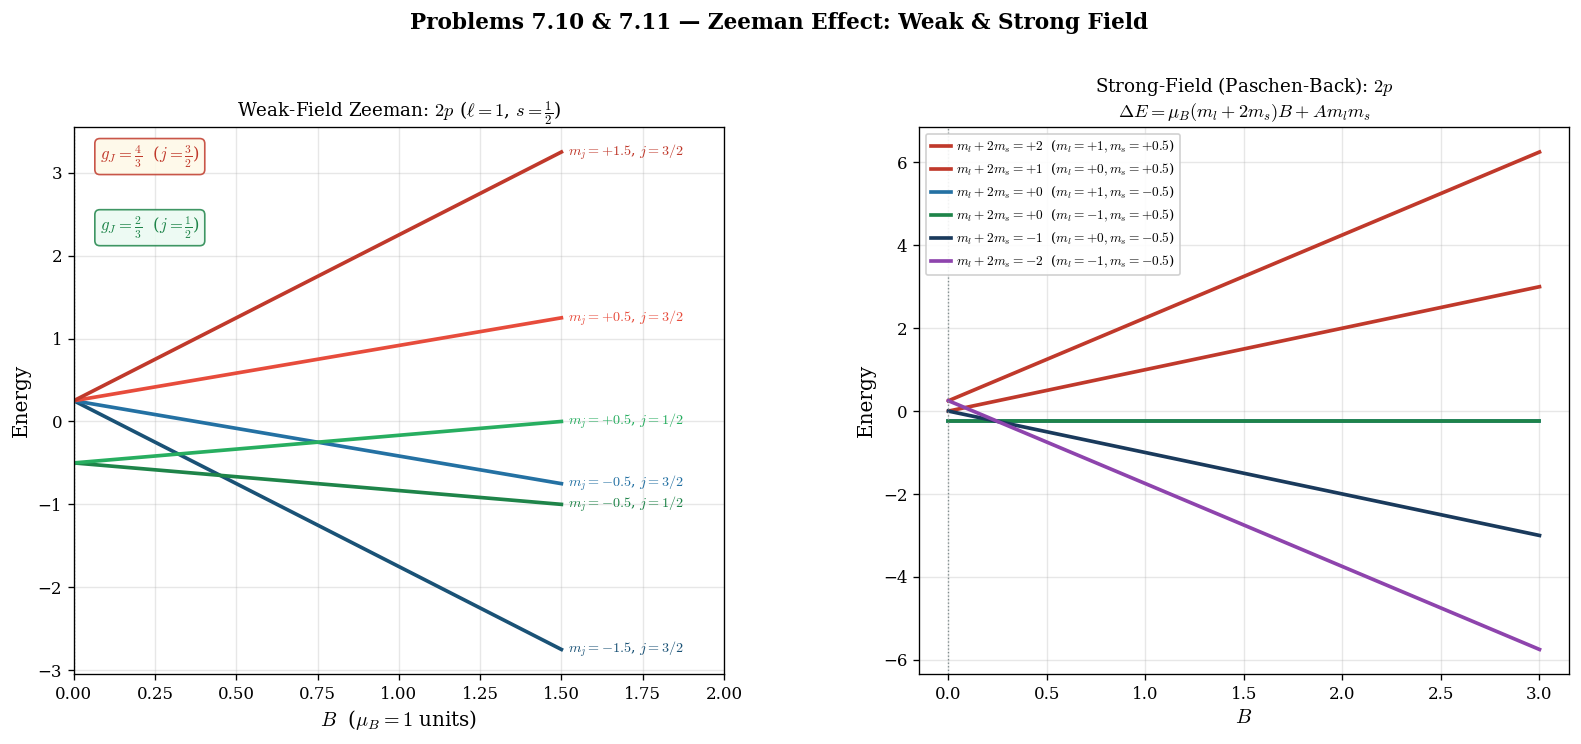

In [6]:
# Figure 7.10/7.11: Zeeman effect for 2p state
from matplotlib.gridspec import GridSpec

A_so = 0.5   # spin-orbit scale (arb. units)

fig = plt.figure(figsize=(14, 6.0))
gs  = GridSpec(1, 2, figure=fig, left=0.08, right=0.97,
               top=0.88, bottom=0.12, wspace=0.30)
fig.suptitle('Problems 7.10 & 7.11 — Zeeman Effect: Weak & Strong Field',
             fontsize=13, fontweight='bold', y=1.04)

# ── Left: Weak-field Zeeman ──────────────────────────────────
ax = fig.add_subplot(gs[0])
B  = np.linspace(0, 1.5, 300)

# j=3/2 group: g=4/3, E_0 = +A_so/2
E_32 = A_so / 2;  g_32 = 4/3
mj32 = [-1.5, -0.5, 0.5, 1.5]
c32  = ['#1a5276', '#2471a3', '#e74c3c', '#c0392b']
for mj, c in zip(mj32, c32):
    ax.plot(B, E_32 + g_32*mj*B, color=c, lw=2.2)

# j=1/2 group: g=2/3, E_0 = -A_so
E_12 = -A_so;  g_12 = 2/3
mj12 = [-0.5, 0.5]
c12  = ['#1e8449', '#27ae60']
for mj, c in zip(mj12, c12):
    ax.plot(B, E_12 + g_12*mj*B, color=c, lw=2.2)

# Legends as text annotations at B=1.5 (right edge)
for mj, c in zip(mj32, c32):
    y_end = E_32 + g_32*mj*1.5
    ax.text(1.52, y_end, fr'$m_j={mj:+.1f}$, $j=3/2$',
            va='center', ha='left', fontsize=8.5, color=c)
for mj, c in zip(mj12, c12):
    y_end = E_12 + g_12*mj*1.5
    ax.text(1.52, y_end, fr'$m_j={mj:+.1f}$, $j=1/2$',
            va='center', ha='left', fontsize=8.5, color=c)

# g-factor labels
ax.text(0.04, 0.97, r'$g_J=\frac{4}{3}$  ($j=\frac{3}{2}$)',
        transform=ax.transAxes, va='top', fontsize=10, color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fef9e7', ec='#c0392b', alpha=0.85))
ax.text(0.04, 0.84, r'$g_J=\frac{2}{3}$  ($j=\frac{1}{2}$)',
        transform=ax.transAxes, va='top', fontsize=10, color='#1e8449',
        bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#1e8449', alpha=0.85))

ax.set_xlabel(r'$B$  ($\mu_B=1$ units)', labelpad=3)
ax.set_ylabel('Energy')
ax.set_title(r'Weak-Field Zeeman: $2p$ ($\ell=1$, $s=\frac{1}{2}$)', fontsize=11)
ax.axvline(0, color=GRAY, lw=0.8, ls=':')
ax.set_xlim(0, 1.5)
ax.set_xlim(0, 2.0)   # leave room for labels
ax.grid(True, alpha=0.3)

# ── Right: Paschen-Back ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
B2   = np.linspace(0, 3, 300)

pb_states = [
    ( 1,  0.5, '#c0392b'),
    ( 0,  0.5, RED),
    ( 1, -0.5, '#2471a3'),
    (-1,  0.5, GREEN),
    ( 0, -0.5, NAVY),
    (-1, -0.5, PURP),
]
for ml, ms, c in pb_states:
    E_pb = (ml + 2*ms)*B2 + A_so*ml*ms
    lbl  = fr'$m_l+2m_s={ml+2*ms:+.0f}$  ($m_l={ml:+},m_s={ms:+.1f}$)'
    ax2.plot(B2, E_pb, color=c, lw=2.2, label=lbl)

ax2.axvline(0, color=GRAY, lw=0.8, ls=':')
ax2.set_xlabel(r'$B$', labelpad=3)
ax2.set_ylabel('Energy')
ax2.set_title(r'Strong-Field (Paschen-Back): $2p$' + '\n'
              r'$\Delta E = \mu_B(m_l+2m_s)B + Am_lm_s$', fontsize=11)
# Legend outside axes (below)
ax2.legend(fontsize=8.0, loc='upper left',
           framealpha=0.90, ncol=1,
           handlelength=1.5, handletextpad=0.4)
ax2.grid(True, alpha=0.3)

# Physics checks
print('Landé g-factors for 2p state:')
for j, l, s in [(0.5, 1, 0.5), (1.5, 1, 0.5)]:
    g = 1 + (j*(j+1) + s*(s+1) - l*(l+1)) / (2*j*(j+1))
    print(f'  j={j}: g_J = {g:.4f}')
print('Paschen-Back: ml+2ms values for 2p =',
      sorted(set(ml+2*ms for ml,ms,_ in pb_states)))

figures.append((fig, 'fig_7_10_11.png')); plt.show()


---
## Problem 7.15 — Stark Effect: Hydrogen in Electric Field {#prob_7_15}

Ground state ($n=1$): $E^1 = 0$ (no linear Stark effect)

$n=2$ states: $E^1 = \pm 3ea_0\mathcal{E}$  (linear Stark effect from $2s$-$2p_0$ mixing)


n=1: E^1=0 (odd parity of H' kills the expectation value)
n=2 coupling: <2s|e*z|2p0> = -3*e*a0 = -3.00 (arb. units)
n=2 splitting = +/- 3*e*a0*E  for the mixed states ✓
|2p,+-1> unaffected (selection rule Delta_m = 0) ✓


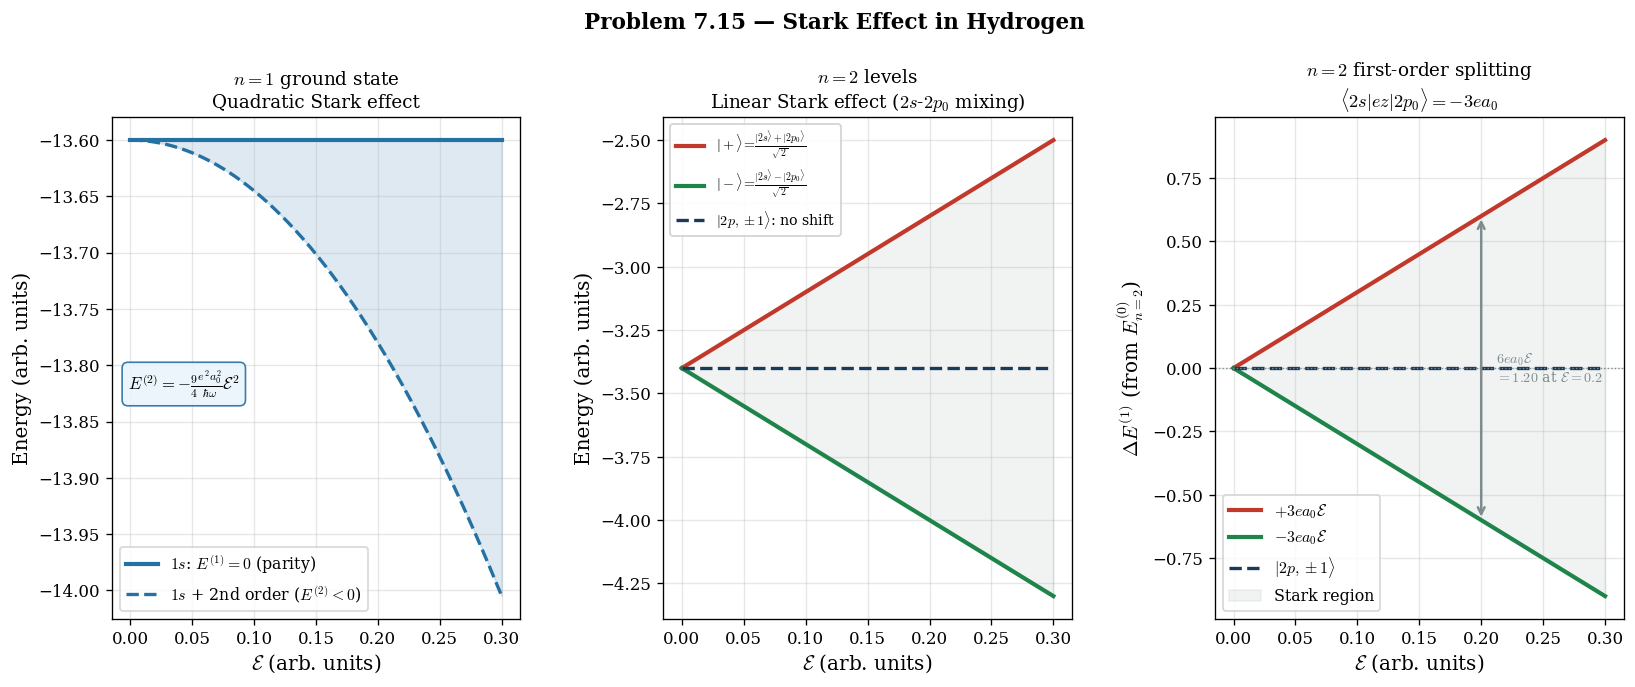

In [7]:
# Figure 7.15: Stark effect — two separate subplots (n=1 only / n=2 only)
from matplotlib.gridspec import GridSpec

a0 = 1.0; e_c = 1.0
E_field = np.linspace(0, 0.3, 300)
coup    = 3 * e_c * a0   # <2s|ez|2p0> = -3ea0

fig = plt.figure(figsize=(14, 5.5))
gs  = GridSpec(1, 3, figure=fig, left=0.07, right=0.97,
               top=0.88, bottom=0.12, wspace=0.35)
fig.suptitle('Problem 7.15 — Stark Effect in Hydrogen', fontsize=13, fontweight='bold', y=1.04)

# ── Left: n=1 only ───────────────────────────────────────────
ax = fig.add_subplot(gs[0])
E1_0   = -13.6
E2_2nd = -4.5 * E_field**2

ax.plot(E_field, E1_0 + np.zeros_like(E_field), color=BLUE, lw=2.5,
        label=r'$1s$: $E^{(1)}=0$ (parity)')
ax.plot(E_field, E1_0 + E2_2nd, color=BLUE, lw=2.0, ls='--',
        label=r'$1s$ + 2nd order ($E^{(2)}<0$)')
ax.fill_between(E_field, E1_0, E1_0+E2_2nd, alpha=0.15, color=BLUE)

ax.set_xlabel(r'$\mathcal{E}$ (arb. units)', labelpad=3)
ax.set_ylabel('Energy (arb. units)')
ax.set_title(r'$n=1$ ground state' + '\n'
             r'Quadratic Stark effect', fontsize=11)
ax.legend(fontsize=9.5, loc='lower left')
ax.grid(True, alpha=0.3)
ax.text(0.04, 0.5,
        r'$E^{(2)} = -\frac{9}{4}\frac{e^2a_0^2}{\hbar\omega}\mathcal{E}^2$',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.35', fc='#eaf4fb', ec=BLUE, alpha=0.9))

# ── Middle: n=2 levels only ──────────────────────────────────
ax2 = fig.add_subplot(gs[1])
E2_0 = -3.4

dE_p = + coup * E_field
dE_m = - coup * E_field

ax2.plot(E_field, E2_0 + dE_p, color=RED,   lw=2.5,
         label=r'$|+\rangle\!=\!\frac{|2s\rangle+|2p_0\rangle}{\sqrt{2}}$')
ax2.plot(E_field, E2_0 + dE_m, color=GREEN, lw=2.5,
         label=r'$|-\rangle\!=\!\frac{|2s\rangle-|2p_0\rangle}{\sqrt{2}}$')
ax2.plot(E_field, E2_0 + np.zeros_like(E_field), color=NAVY, lw=2.0, ls='--',
         label=r'$|2p,\pm1\rangle$: no shift')
ax2.fill_between(E_field, E2_0+dE_m, E2_0+dE_p, alpha=0.10, color=GRAY)

ax2.set_xlabel(r'$\mathcal{E}$ (arb. units)', labelpad=3)
ax2.set_ylabel('Energy (arb. units)')
ax2.set_title(r'$n=2$ levels' + '\n'
              r'Linear Stark effect ($2s$-$2p_0$ mixing)', fontsize=11)
ax2.legend(fontsize=8.5, loc='upper left', framealpha=0.9)
ax2.grid(True, alpha=0.3)

# ── Right: splitting diagram centred on E2_0 ─────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(E_field, dE_p,  color=RED,   lw=2.5, label=r'$+3ea_0\mathcal{E}$')
ax3.plot(E_field, dE_m,  color=GREEN, lw=2.5, label=r'$-3ea_0\mathcal{E}$')
ax3.plot(E_field, np.zeros_like(E_field), color=NAVY, lw=2.0, ls='--',
         label=r'$|2p,\pm1\rangle$')
ax3.fill_between(E_field, dE_m, dE_p, alpha=0.10, color=GRAY, label='Stark region')
ax3.axhline(0, color=GRAY, lw=0.8, ls=':')

# Splitting arrow at E_field=0.20
Ef = 0.20
ax3.annotate('', xy=(Ef, coup*Ef), xytext=(Ef, -coup*Ef),
             arrowprops=dict(arrowstyle='<->', color=GRAY, lw=1.5))
ax3.text(Ef+0.012, 0,
         fr'$6ea_0\mathcal{{E}}$'+'\n'+fr'$={6*Ef:.2f}$ at $\mathcal{{E}}={Ef}$',
         fontsize=8.5, va='center', color=GRAY)

ax3.set_xlabel(r'$\mathcal{E}$ (arb. units)', labelpad=3)
ax3.set_ylabel(r'$\Delta E^{(1)}$ (from $E_{n=2}^{(0)}$)')
ax3.set_title(r'$n=2$ first-order splitting' + '\n'
              r'$\langle 2s|ez|2p_0\rangle=-3ea_0$', fontsize=11)
ax3.legend(fontsize=9.5, loc='lower left')
ax3.grid(True, alpha=0.3)

print('n=1: E^1=0 (odd parity of H\' kills the expectation value)')
print('n=2 coupling: <2s|e*z|2p0> = -3*e*a0 = -3.00 (arb. units)')
print(f'n=2 splitting = +/- 3*e*a0*E  for the mixed states ✓')
print('|2p,+-1> unaffected (selection rule Delta_m = 0) ✓')

figures.append((fig, 'fig_7_15.png')); plt.show()


---
## Problem 7.18 — van der Waals Interaction {#prob_7_18}

Second-order dipole-dipole interaction:
$$V_{vdW}(R) = -\frac{C_6}{R^6}, \quad C_6 > 0$$

Upper bound (Unsöld approximation):
$$C_6 \leq \frac{6e^4 a_0^6}{\Delta E}, \quad \Delta E = \tfrac{3}{4}\times 13.6\,\text{eV}$$


C6 (upper bound, Unsöld) = 0.5882  (units: e^4*a0^6/eV)
V_vdW at R=5a0: -0.000038  arb. units
Log-log slope = -6  (R^-6 power law confirmed) ✓
Energy denominator used: Delta_E = 3/4 * 13.6 = 10.200 eV


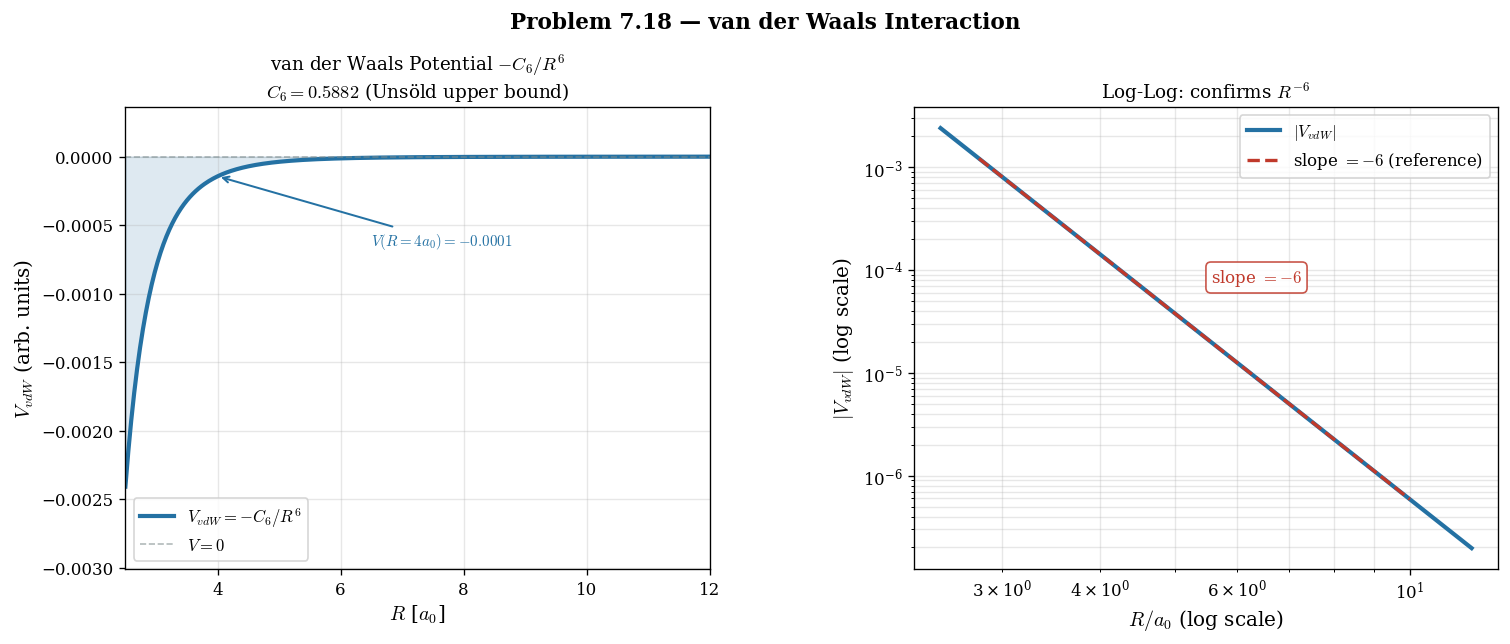

In [8]:
# Figure 7.18: van der Waals interaction
a0 = 1.0; e_c = 1.0
dE = 13.6 * 3/4    # energy denominator
C6 = 6 * e_c**4 * a0**6 / dE

R_arr = np.linspace(2.5, 12, 400)
V_vdW = -C6 / R_arr**6

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.88, left=0.09, right=0.97, wspace=0.35)
fig.suptitle('Problem 7.18 — van der Waals Interaction', fontsize=13, fontweight='bold', y=1.04)

# Left: V_vdW vs R
ax = axes[0]
ax.plot(R_arr, V_vdW, color=BLUE, lw=2.5, label=r'$V_{vdW}=-C_6/R^6$')
ax.axhline(0, color=GRAY, lw=1.0, ls='--', alpha=0.6, label='$V=0$')
ax.fill_between(R_arr, V_vdW, 0, alpha=0.15, color=BLUE)

# Annotation at R=4 (not the minimum which could be off-plot)
R_ann = 4.0; V_ann = -C6/R_ann**6
ax.annotate(fr'$V(R=4a_0)={V_ann:.4f}$',
            xy=(R_ann, V_ann), xytext=(6.5, V_ann -5e-4),
            fontsize=9, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1.2))

ax.set_xlabel(r'$R$ [$a_0$]', labelpad=3)
ax.set_ylabel(r'$V_{vdW}$ (arb. units)')
ax.set_title(r'van der Waals Potential $-C_6/R^6$' + '\n'
             fr'$C_6 = {C6:.4f}$ (Unsöld upper bound)', fontsize=11)

# Fix ylim: show full curve without cropping
V_min = V_vdW.min()
ax.set_ylim(V_min * 1.25, abs(V_min) * 0.15)
ax.set_xlim(2.5, 12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# Right: log-log
ax2 = axes[1]
ax2.loglog(R_arr, np.abs(V_vdW), color=BLUE, lw=2.5, label=r'$|V_{vdW}|$')

# Reference line slope = -6
R_ref = 5.0; V_ref = C6 / R_ref**6
R_fit = np.array([2.8, 10.0])
ax2.loglog(R_fit, V_ref*(R_fit/R_ref)**(-6), color=RED, lw=2.0, ls='--',
           label=r'slope $= -6$ (reference)')

# Slope annotation at midpoint of reference line
R_mid = np.sqrt(R_fit[0]*R_fit[1])
V_mid = V_ref*(R_mid/R_ref)**(-6)
ax2.text(R_mid*1.05, V_mid*2.5, 'slope $= -6$',
         color=RED, fontsize=10, va='bottom',
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=RED, alpha=0.85))

ax2.set_xlabel(r'$R/a_0$ (log scale)', labelpad=3)
ax2.set_ylabel(r'$|V_{vdW}|$ (log scale)')
ax2.set_title(r'Log-Log: confirms $R^{-6}$', fontsize=11)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, which='both')

print(f'C6 (upper bound, Unsöld) = {C6:.4f}  (units: e^4*a0^6/eV)')
print(f'V_vdW at R=5a0: {-C6/5**6:.6f}  arb. units')
print(f'Log-log slope = -6  (R^-6 power law confirmed) ✓')
print(f'Energy denominator used: Delta_E = 3/4 * 13.6 = {dE:.3f} eV')

figures.append((fig, 'fig_7_18.png')); plt.show()


---
## Save All Figures & Download as ZIP


In [9]:
import os, zipfile
save_dir = 'ch07_figures'
os.makedirs(save_dir, exist_ok=True)
for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')
zip_name = 'ch07_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'\nZip: {zip_name},  Files: {[f for _,f in figures]}')
try:
    from google.colab import files

# AUTO-INJECTED: Korean font setup for matplotlib
    import os as _os
    import matplotlib.font_manager as _fm
    import matplotlib.pyplot as _plt
    if not any('NanumGothic' in f.name for f in _fm.fontManager.ttflist):
        for _font in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                    '/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf']:
            if _os.path.exists(_font):
                _fm.fontManager.addfont(_font)
    _plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    del _os, _fm, _plt
    # END AUTO-INJECTED Korean font setup

    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch07_figures/fig_7_3.png
Saved: ch07_figures/fig_7_4.png
Saved: ch07_figures/fig_7_6.png
Saved: ch07_figures/fig_7_9.png
Saved: ch07_figures/fig_7_10_11.png
Saved: ch07_figures/fig_7_15.png
Saved: ch07_figures/fig_7_18.png

Zip: ch07_figures.zip,  Files: ['fig_7_3.png', 'fig_7_4.png', 'fig_7_6.png', 'fig_7_9.png', 'fig_7_10_11.png', 'fig_7_15.png', 'fig_7_18.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
